In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh, solve_banded

In [2]:
%matplotlib widget

In [3]:
data = np.load('/home/sthoma/Documents/Results/MU04/Inversions/sys_err_5_scale_2.5x.npz')
R = data['R']
frame = data['frame']
R_grid = data['R_grid']
y = data['y']
y_err = data['y_err']
backprojection = data['backprojection'][0]

n = 11
R = np.zeros((n, len(R)))
frame = np.zeros((n, len(frame)))
R_grid = np.zeros((n, len(R_grid)))
y = np.zeros((n, len(y)))
y_err = np.zeros((n, len(y_err)))
backprojection = np.zeros((n, len(backprojection)))

data = np.load('/home/sthoma/Documents/Results/MU04/Inversions/sys_err_5_scale_2.5x.npz')
R[0] = data['R']
frame[0] = data['frame']
R_grid[0] = data['R_grid']
y[0] = data['y']
y_err[0] = data['y_err']
backprojection[0] = data['backprojection'][0]

for i in range(1, n):
    data = np.load(f'/home/sthoma/Documents/Results/MU04/Inversions/sys_err_5_scale_2.5x_nboxcar_{i*2+1}.npz')
    R[i] = data['R']
    frame[i] = data['frame']
    R_grid[i] = data['R_grid']
    y[i] = data['y']
    y_err[i] = data['y_err']
    backprojection[i] = data['backprojection'] 

In [4]:
from matplotlib.colors import Normalize
def normalise(xx):
    vmin = xx.min()
    vmax = xx.max()
    return (xx - vmin)/(vmax-vmin)

In [5]:
R_grid_b = (R_grid[0,1:]+ R_grid[0,:-1])/2

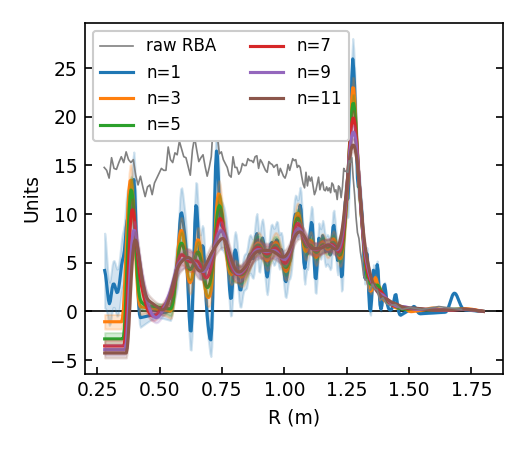

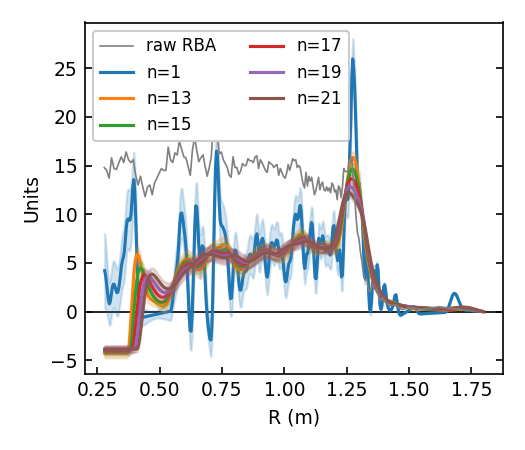

In [6]:
sys_err = np.arange(1, 20.1, 1)
cmap = plt.cm.viridis
norm = Normalize(vmin=sys_err[0], vmax=sys_err[-1])
colors = normalise(sys_err)
c = cmap(colors)

xplot = [0.2,1.875]

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R[0], frame[0], '-', c='gray', lw=0.8, zorder=3, label='raw RBA')
i = 0
ax.plot(R_grid_b, y[i], '-', c='C0', zorder=2, label='n=1')
ax.fill_between(R_grid_b, y[i]-y_err[i], y[i]+y_err[i], color='C0', alpha=0.2, zorder=2)
for i in range(1, 6):
    ax.plot(R_grid_b, y[i], '-', c=f'C{i}', zorder=2, label=f'n={2*i+1}')
    ax.fill_between(R_grid_b, y[i]-y_err[i], y[i]+y_err[i], color=f'C{i}', alpha=0.2, zorder=2)
ax.set_xlim(xplot)
ax.plot(xplot, [0.,0.], '-k', lw=0.8, zorder=1)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Units', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8, ncol=2)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=False)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(R[0], frame[0], '-', c='gray', lw=0.8, zorder=3, label='raw RBA')
i = 0
ax.plot(R_grid_b, y[i], '-', c='C0', zorder=2, label='n=1')
ax.fill_between(R_grid_b, y[i]-y_err[i], y[i]+y_err[i], color='C0', alpha=0.2, zorder=2)
for i in range(6, 11):
    ax.plot(R_grid_b, y[i], '-', c=f'C{i-5}', zorder=2, label=f'n={2*i+1}')
    ax.fill_between(R_grid_b, y[i]-y_err[i], y[i]+y_err[i], color=f'C{i-5}', alpha=0.2, zorder=2)
ax.set_xlim(xplot)
ax.plot(xplot, [0.,0.], '-k', lw=0.8, zorder=1)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Units', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8, ncol=2)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=False)
plt.tight_layout()